In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
import warnings


In [3]:
df = pd.read_csv('stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']

In [7]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [30]:
X = df.drop(columns=['writing_score'],axis=1)

In [31]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,218
1,female,group C,some college,standard,completed,69,90,247
2,female,group B,master's degree,standard,none,90,95,278
3,male,group A,associate's degree,free/reduced,none,47,57,148
4,male,group C,some college,standard,none,76,78,229


In [32]:
y = df['writing_score']

In [33]:
y

0      74
1      88
2      93
3      44
4      75
       ..
995    95
996    55
997    65
998    77
999    86
Name: writing_score, Length: 1000, dtype: int64

In [34]:
# Converting categorical features to numerical
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [35]:
X=preprocessor.fit_transform(X)

In [36]:
X.shape

(1000, 20)

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 20), (200, 20))

    Creating an evaluation function

In [38]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [39]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000


Lasso
Model performance for Training set
- Root Mean Squared Error: 3.6680
- Mean Absolute Error: 2.9703
- R2 Score: 0.9408
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 3.9935
- Mean Absolute Error: 3.2416
- R2 Score: 0.9338


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.7001
- Mean Absolute Error: 0.5625
- R2 Score: 0.9978
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.8017
- Mean Absolute Error: 0.6640
- R2 Score: 0.9973


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 3.4360
- Mean Absolute Error: 2.7415
- R2 Score: 0.9481
-----------------------

In [40]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
0,Linear Regression,1.000000
2,Ridge,0.997333
5,Random Forest Regressor,0.967519
6,CatBoosting Regressor,0.965100
7,AdaBoost Regressor,0.941506
4,Decision Tree,0.936706
1,Lasso,0.933829
3,K-Neighbors Regressor,0.918397


Ridge Regression

In [41]:
ridge_model=Ridge()
ridge_model=ridge_model.fit(X_train,y_train)
y_pred=ridge_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print('Accuracy of the model: ', score)

Accuracy of the model:  99.73330006250276


Text(0.5, 0, 'Predicted')

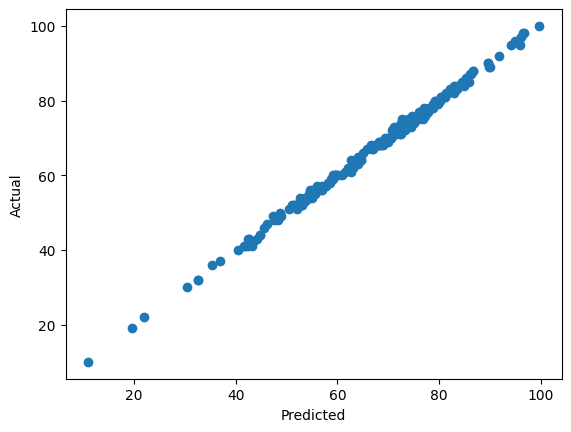

In [42]:
plt.scatter(y_pred,y_test)
plt.ylabel('Actual')
plt.xlabel('Predicted')

Random Forest

In [43]:
rf_model=RandomForestRegressor()
rf_model=rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print('Accuracy of the model: ', score)

Accuracy of the model:  96.80702158011898


Text(0.5, 0, 'Predicted')

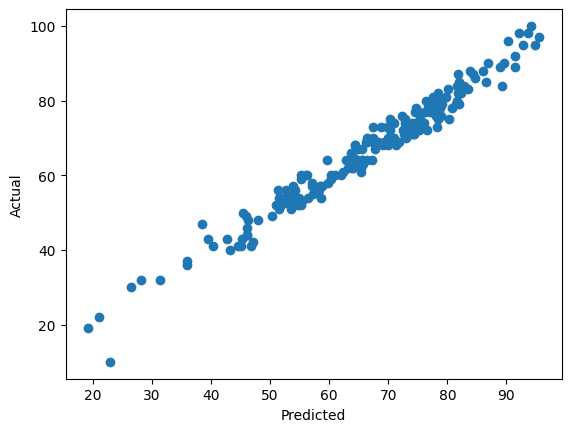

In [44]:
plt.scatter(y_pred,y_test)
plt.ylabel('Actual')
plt.xlabel('Predicted')